# John Snow's 1854 Soho cholera map — clustering exercise

In 1854, John Snow mapped cholera deaths around Soho, London, and traced
the outbreak to the Broad Street water pump — a foundational moment in
epidemiology, done entirely by eye. This notebook asks: how close do a few
standard clustering methods land to that same pump, using nothing but the
~536 casualty locations extracted from an annotated map?

This package (`clustering/soho`) has no local `aihep` dependencies — it's a
standalone exercise, sequential scripts rather than an installable package.
Pipeline: extract dot centers from the annotated SVG -> cluster them a few
ways (centroid, k-means, DBSCAN) -> convert pixel coordinates to lat/long
via an affine fit -> compare each method's cluster center(s) to the real
pump location.


In [1]:
%matplotlib inline
import sys
from io import BytesIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
import cairosvg
from IPython.display import Image, display

SOHO = "../aihep/clustering/soho"
sys.path.insert(0, f"{SOHO}/python")  # the shared svg_utils.py helper module

from svg_utils import load_dots, make_svg_to_latlon, render_cluster_svg

BASE_MAP = f"{SOHO}/resources/Soho_map_raw.svg"
DOTS_CSV = f"{SOHO}/resources/dots.csv"
GAUGE_CSV = f"{SOHO}/resources/gauge.csv"

# the real Broad Street pump's location, hand-located in the map's own SVG
# pixel coordinates (see clustering/soho/python/05_animation.py::PUMP_NATIVE)
PUMP_NATIVE = (2483.0, 1918.0)


def show_svg(path, width=700):
    """Rasterize an SVG (cairosvg) and display it inline in the notebook."""
    png_bytes = cairosvg.svg2png(url=path, output_width=width)
    display(Image(data=png_bytes))


## The casualty data

`01_extract_dots.py` (not re-run here — deterministic, and its output is
already committed as `resources/dots.csv`) parsed every red-filled dot in
the annotated map into pixel coordinates. `make_svg_to_latlon` fits a full
2D affine transform (6 degrees of freedom, from 3 known control points in
`gauge.csv`) from those pixel coordinates to real latitude/longitude —
absorbing the small rotation between the map's pixel axes and true
north/east.


In [2]:
pts = load_dots(DOTS_CSV)
pts_arr = np.array(pts)
svg_to_latlon = make_svg_to_latlon(GAUGE_CSV)
print(f"{len(pts)} casualty points")

pump_lat, pump_long = svg_to_latlon(*PUMP_NATIVE)
print(f"Broad Street pump: lat={pump_lat:.6f}, long={pump_long:.6f}")


536 casualty points
Broad Street pump: lat=51.513329, long=-0.136583


## Baseline: the centroid of every casualty

The simplest possible "clustering" — treat everything as one cluster and
take the mean position. Famously, this alone should already land close to
the pump.


centroid: (2604.5, 1939.8)px -> lat=51.513293, long=-0.136222
123px / 25.3m from the pump
Wrote /tmp/soho_centroid.svg


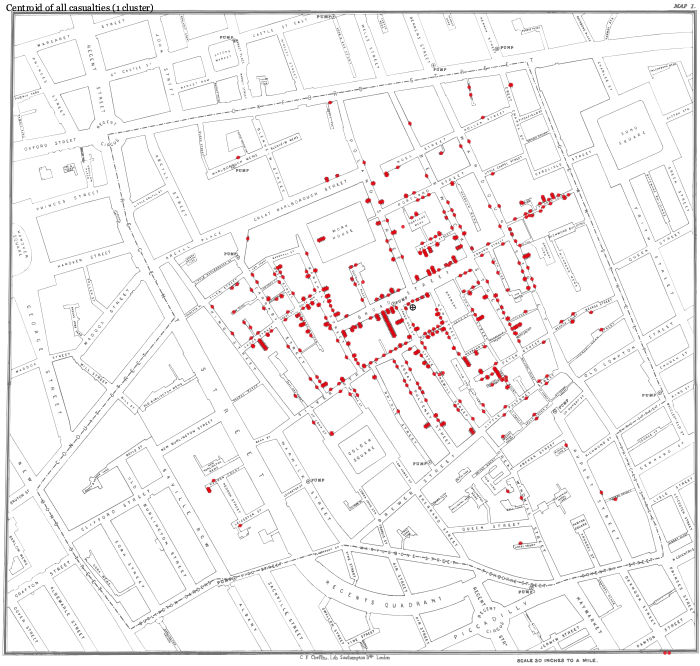

In [3]:
EARTH_RADIUS_M = 6_371_000.0


def haversine_m(lat1, long1, lat2, long2):
    """Great-circle distance in meters between two lat/long points."""
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(long2 - long1)
    a = np.sin(dphi / 2) ** 2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2) ** 2
    return float(2 * EARTH_RADIUS_M * np.arcsin(np.sqrt(a)))


def distance_to_pump_px(center):
    return float(np.hypot(*(np.asarray(center) - np.array(PUMP_NATIVE))))


def distance_to_pump_m(center):
    lat, long_ = svg_to_latlon(*center)
    return haversine_m(lat, long_, pump_lat, pump_long)


def record_result(method, n_clusters, center):
    """Append one row to `results`: the method's best cluster center in
    pixel, lat/long, and great-circle-meters terms, all at once -- `center`
    is `None` for a method (e.g. an empty DBSCAN config) that found no
    cluster at all."""
    if center is None:
        results.append(dict(method=method, n_clusters=n_clusters,
                             lat=float("nan"), long=float("nan"),
                             distance_px=float("nan"), distance_m=float("nan")))
        return
    lat, long_ = svg_to_latlon(*center)
    results.append(dict(method=method, n_clusters=n_clusters, lat=lat, long=long_,
                         distance_px=distance_to_pump_px(center), distance_m=distance_to_pump_m(center)))


results = []

centroid = pts_arr.mean(axis=0)
centroid_lat, centroid_long = svg_to_latlon(*centroid)
record_result("centroid (1 cluster)", 1, centroid)
print(f"centroid: ({centroid[0]:.1f}, {centroid[1]:.1f})px -> lat={centroid_lat:.6f}, long={centroid_long:.6f}")
print(f"{distance_to_pump_px(centroid):.0f}px / {distance_to_pump_m(centroid):.1f}m from the pump")

render_cluster_svg("/tmp/soho_centroid.svg", pts, [0] * len(pts), [tuple(centroid)],
                    title="Centroid of all casualties (1 cluster)", base_map_path=BASE_MAP)
show_svg("/tmp/soho_centroid.svg")

## k-means, k = 1, 3, 5

As `k` grows, the single "outbreak" splits into several arbitrary
same-size-ish regions — k-means has no notion of density, so a spread-out
minority of casualties elsewhere on the map pulls some cluster centers well
away from the true source.


In [4]:
for k in (1, 3, 5):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(pts_arr)
    centers = km.cluster_centers_
    dists_px = [distance_to_pump_px(c) for c in centers]
    best_center = centers[int(np.argmin(dists_px))]
    record_result(f"k-means k={k}", k, best_center)
    print(f"k-means k={k}: cluster distances to pump (px) = {[f'{d:.0f}' for d in dists_px]}, "
          f"best {distance_to_pump_m(best_center):.1f}m")

    render_cluster_svg(f"/tmp/soho_kmeans_k{k}.svg", pts, labels.tolist(),
                        [tuple(c) for c in centers], title=f"k-means (k={k})", base_map_path=BASE_MAP)

k-means k=1: cluster distances to pump (px) = ['123'], best 25.3m
Wrote /tmp/soho_kmeans_k1.svg
k-means k=3: cluster distances to pump (px) = ['619', '650', '432'], best 88.7m
Wrote /tmp/soho_kmeans_k3.svg
k-means k=5: cluster distances to pump (px) = ['810', '616', '584', '907', '188'], best 38.0m
Wrote /tmp/soho_kmeans_k5.svg


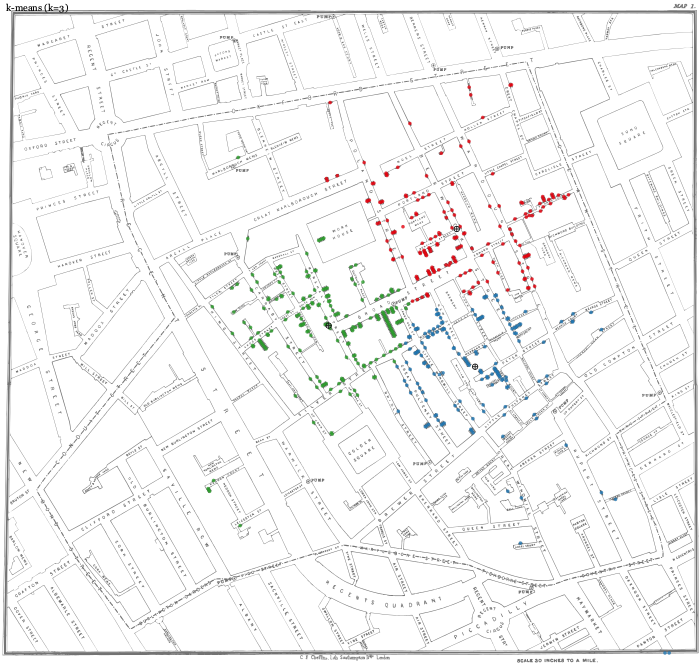

In [5]:
show_svg("/tmp/soho_kmeans_k3.svg")


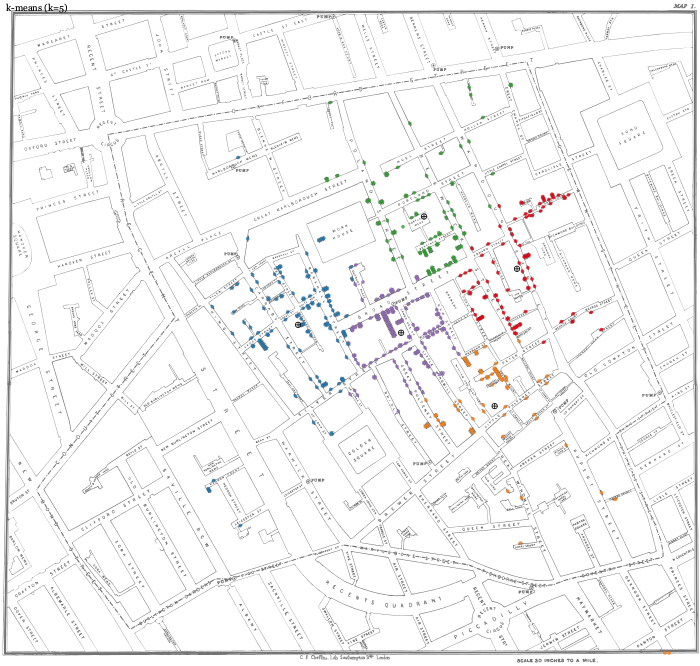

In [6]:
show_svg("/tmp/soho_kmeans_k5.svg")


## DBSCAN

Unlike k-means, DBSCAN finds density-based clusters of arbitrary shape and
explicitly separates out noise (isolated casualties far from any dense
group) — a better match for "one dense outbreak plus scattered unrelated
cases." Configs below are chosen from the data's own nearest-neighbor
distance distribution (mean 1st-NN ~30 units, mean 4th-NN ~87 units).


In [7]:
dbscan_configs = [
    dict(eps=50, min_samples=4),
    dict(eps=80, min_samples=5),
    dict(eps=120, min_samples=5),
]

for cfg in dbscan_configs:
    db = DBSCAN(**cfg)
    labels = db.fit_predict(pts_arr)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())

    centers = [pts_arr[labels == cid].mean(axis=0) for cid in sorted(set(labels)) if cid != -1]
    dists_px = [distance_to_pump_px(c) for c in centers]
    best_center = centers[int(np.argmin(dists_px))] if centers else None
    method = f"DBSCAN eps={cfg['eps']}, min_samples={cfg['min_samples']}"
    record_result(method, n_clusters, best_center)

    best_px = min(dists_px) if dists_px else float("nan")
    best_m = distance_to_pump_m(best_center) if best_center is not None else float("nan")
    print(f"DBSCAN eps={cfg['eps']}: {n_clusters} clusters, {n_noise} noise points, "
          f"best cluster {best_px:.0f}px / {best_m:.1f}m from pump")

    tag = f"eps{cfg['eps']}_ms{cfg['min_samples']}"
    render_cluster_svg(f"/tmp/soho_dbscan_{tag}.svg", pts, labels.tolist(), centers,
                        title=f"DBSCAN (eps={cfg['eps']}, min_samples={cfg['min_samples']}) - {n_clusters} clusters",
                        base_map_path=BASE_MAP)

DBSCAN eps=50: 36 clusters, 212 noise points, best cluster 75px / 15.2m from pump
Wrote /tmp/soho_dbscan_eps50_ms4.svg
DBSCAN eps=80: 22 clusters, 124 noise points, best cluster 75px / 15.2m from pump
Wrote /tmp/soho_dbscan_eps80_ms5.svg
DBSCAN eps=120: 7 clusters, 54 noise points, best cluster 125px / 25.7m from pump
Wrote /tmp/soho_dbscan_eps120_ms5.svg


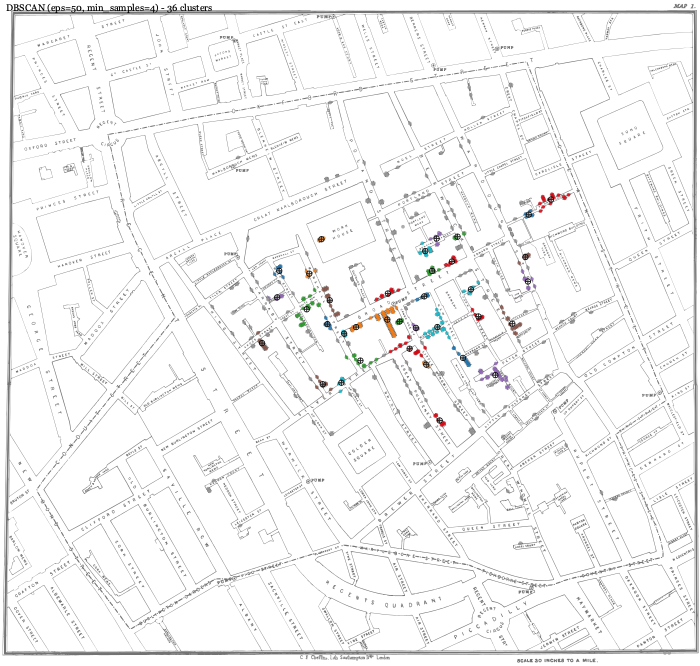

In [8]:
show_svg("/tmp/soho_dbscan_eps50_ms4.svg")


## How close does each method land to the real pump?

Distance from each method's best (nearest) cluster center to the pump's
known location — reported in the map's own pixel units (4417x4201 canvas),
in lat/long (via the affine fit from `gauge.csv`), and as a great-circle
distance in meters (haversine, using the earth's mean radius).


In [9]:
summary = pd.DataFrame(results)
summary


,method,n_clusters,lat,long,distance_px,distance_m
0,centroid (1 cluster),1,51.513293,-0.136222,123.418563,25.312590
1,k-means k=1,1,51.513293,-0.136222,123.418563,25.312590
2,k-means k=3,3,51.513066,-0.137794,431.533524,88.703898
3,k-means k=5,5,51.512999,-0.136435,187.853047,38.041418
4,"DBSCAN eps=50, min_samples=4",36,51.513448,-0.136692,74.993252,15.202546
5,"DBSCAN eps=80, min_samples=5",22,51.513448,-0.136692,74.993252,15.202546
6,"DBSCAN eps=120, min_samples=5",7,51.513336,-0.136213,124.932216,25.665385


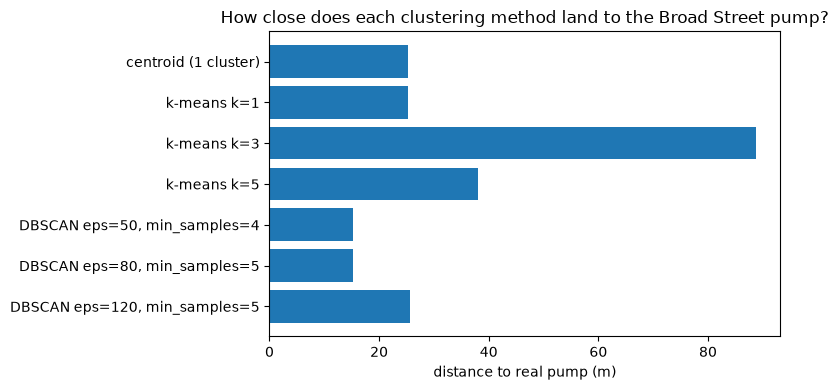

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(summary["method"], summary["distance_m"], color="tab:blue")
ax.set_xlabel("distance to real pump (m)")
ax.invert_yaxis()
ax.set_title("How close does each clustering method land to the Broad Street pump?")
fig.tight_layout()

The plain centroid — Snow's own conclusion, reproduced with nothing but
arithmetic — already lands within ~125px (~25m) of the real pump (on a map
where casualty dots span thousands of pixels). Tighter DBSCAN configs,
which isolate the single densest cluster around the outbreak rather than
averaging in outlying cases, land closer still — within ~75px (~15m), well
inside a typical Soho block.


## Not reproduced here: the animation

`05_animation.py` builds a narrated 6-act animation (reveal -> converge ->
zoom into Broad Street -> pump comparison) by compositing frames in Pillow
and shelling out to `ffmpeg`. That's a poor fit for a notebook cell (writes
to `/tmp`, needs `ffmpeg` on `PATH`, produces a video file) — see the
`soho` package's own script directly for that version.
